In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

color_price_first = "#7402d8"  # purple
color_bid_first = "#d87402"    # orange
color_adaptive = "#02a875"     # green

output_dir = "."


def load_data_only(path):
    df = pd.read_csv(path)
    if "query_type" in df.columns:
        df = df[df["query_type"] == "data"]
    return df

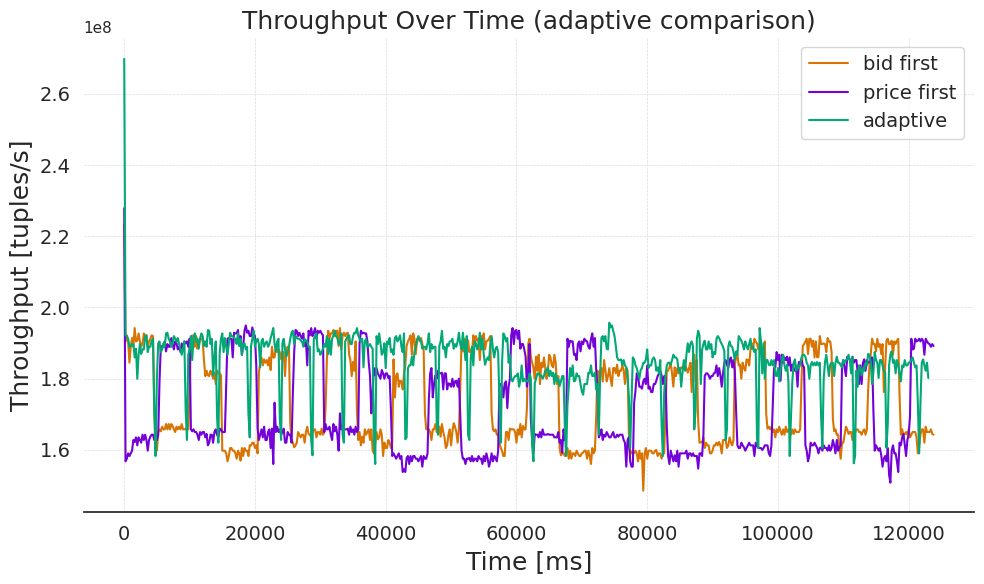

In [2]:
import glob
import os

comparison_dir = "adaptive_comparison"
color_map = {
    "price_first": color_price_first,
    "bid_first": color_bid_first,
    "adaptive": color_adaptive,
}
fallback_palette = sns.color_palette("tab10")

fig, ax = plt.subplots(figsize=(10, 6))

csv_paths = sorted(
    glob.glob(os.path.join(comparison_dir, "*.csv")),
    key=lambda p: ("adaptive" in os.path.basename(p), os.path.basename(p)),
)
for i, path in enumerate(csv_paths):
    name = os.path.splitext(os.path.basename(path))[0]
    df = load_data_only(path)
    color = color_map.get(name, fallback_palette[i % len(fallback_palette)])
    ax.plot(
        df["timestamp_ms"],
        df["throughput_tup_per_s"],
        color=color,
        linewidth=1.5,
        label=name.replace("_", " "),
    )

ax.set_xlabel("Time [ms]", fontsize=18)
ax.set_ylabel("Throughput [tuples/s]", fontsize=18)
ax.set_title("Throughput Over Time (adaptive comparison)", fontsize=18)
ax.tick_params(labelsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(fontsize=14)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig(f"{output_dir}/throughput_over_time_adaptive_comparison.pdf")
plt.show()

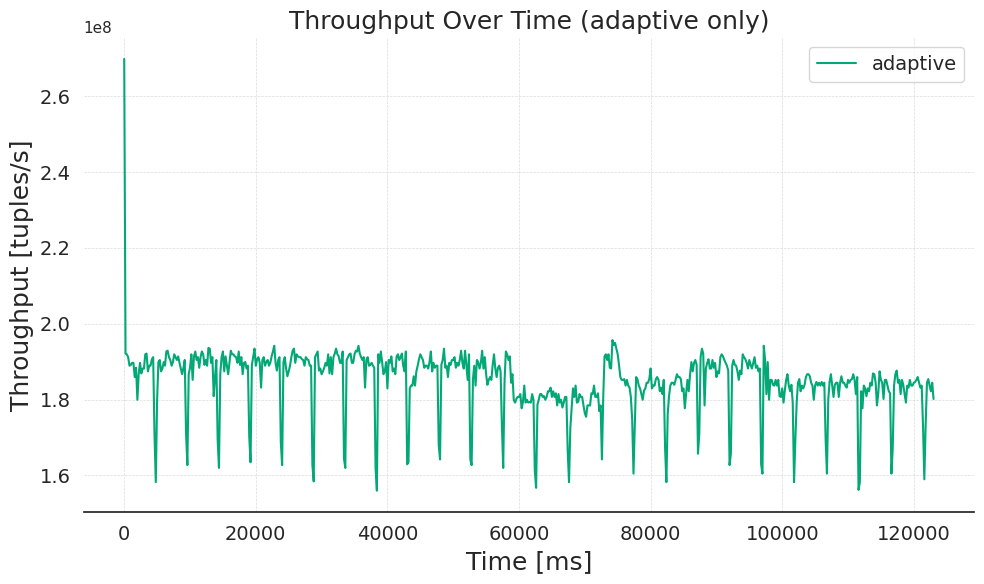

In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

adaptive_path = os.path.join(comparison_dir, "adaptive.csv")
df_adaptive_only = load_data_only(adaptive_path)

ax.plot(
    df_adaptive_only["timestamp_ms"],
    df_adaptive_only["throughput_tup_per_s"],
    color=color_adaptive,
    linewidth=1.5,
    label="adaptive",
)

ax.set_xlabel("Time [ms]", fontsize=18)
ax.set_ylabel("Throughput [tuples/s]", fontsize=18)
ax.set_title("Throughput Over Time (adaptive only)", fontsize=18)
ax.tick_params(labelsize=14)
ax.grid(True, which="both", linestyle="--", linewidth=0.5, alpha=0.7)
ax.legend(fontsize=14)
sns.despine(ax=ax, left=True)

plt.tight_layout()
plt.savefig(f"{output_dir}/throughput_over_time_adaptive_only.pdf")
plt.show()